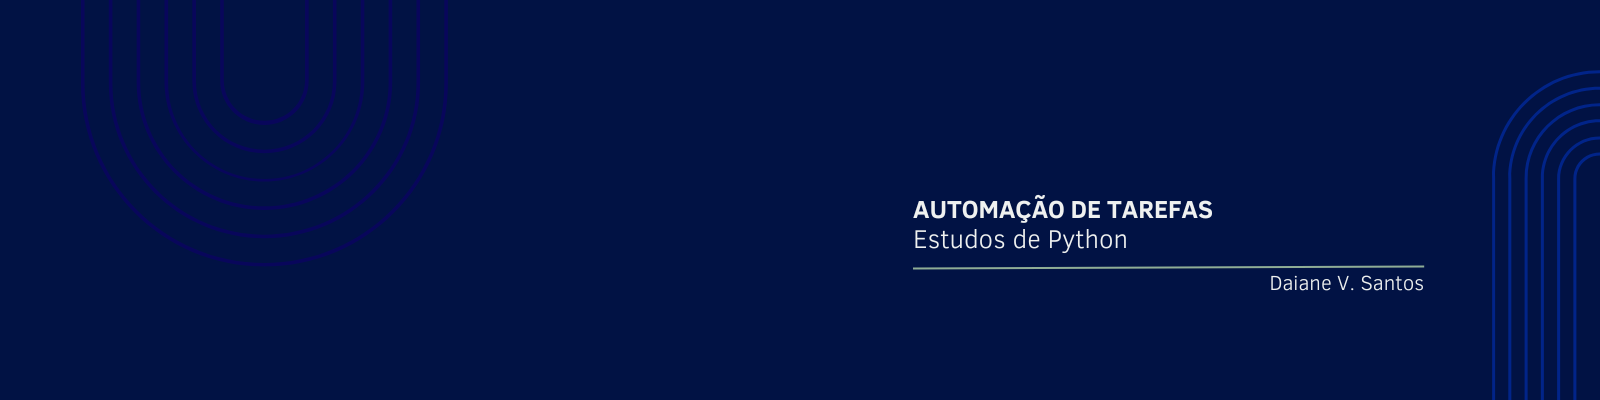

In [ ]:
import os
import fitz  # PyMuPDF
import re
import pyautogui
import time
import pyperclip
import unicodedata
import zipfile

# 🔧 CONFIGURAÇÕES
pyautogui.PAUSE = 1
downloads_path = os.path.join(os.path.expanduser("~"), "Downloads")
pasta_extracao = os.path.join(downloads_path, "extracao_temp")

# 🟩 PASSO 4 a 6: Interação na página
pyautogui.click(x=1274, y=426)  # seta
time.sleep(1)
pyautogui.click(x=1276, y=593)  # integração de documentos
time.sleep(1)
pyautogui.click(x=966, y=254)   # documentos assinados
time.sleep(1)
pyautogui.click(x=992, y=148)   # botão "Abrir" do ZIP
print("⏳ Aguardando abertura do ZIP...")
time.sleep(5)

# 🟨 Localizar ZIP mais recente
zip_mais_recente = None
tempo_mais_recente = 0

for nome in os.listdir(downloads_path):
    if nome.lower().startswith("unico") and nome.lower().endswith(".zip"):
        caminho = os.path.join(downloads_path, nome)
        tempo = os.path.getctime(caminho)
        if tempo > tempo_mais_recente:
            zip_mais_recente = caminho
            tempo_mais_recente = tempo

if not zip_mais_recente:
    print("❌ Nenhum arquivo ZIP 'unico' encontrado.")
    exit()

print(f"📦 ZIP encontrado: {zip_mais_recente}")

# 🟨 Extrair ZIP
if os.path.exists(pasta_extracao):
    for f in os.listdir(pasta_extracao):
        os.remove(os.path.join(pasta_extracao, f))
else:
    os.makedirs(pasta_extracao)

with zipfile.ZipFile(zip_mais_recente, 'r') as zip_ref:
    zip_ref.extractall(pasta_extracao)

# 🟨 Localizar o PDF
def normalizar(texto):
    return unicodedata.normalize("NFKD", texto).encode("ASCII", "ignore").decode("utf-8").lower()

caminho_pdf = None
for root, dirs, files in os.walk(pasta_extracao):
    for nome in files:
        if "termo de consentimento" in normalizar(nome) and nome.lower().endswith(".pdf"):
            caminho_pdf = os.path.join(root, nome)

if not caminho_pdf:
    print("❌ PDF com 'termo de consentimento' não encontrado na extração.")
    exit()

print(f"📄 PDF localizado: {caminho_pdf}")

# 🧠 Ler o PDF e extrair o IP
doc = fitz.open(caminho_pdf)
texto = ""
for page in doc:
    texto += page.get_text()

match = re.search(r"(\d{1,3}(?:\.\d{1,3}){3}):\d+", texto)

if match:
    ip = match.group(1)
    print(f"✅ IP extraído: {ip}")
else:
    print("⚠️ Nenhum IP encontrado no PDF.")
    exit()

# 🟩 Preencher IP no sistema
pyautogui.hotkey('alt', 'tab')
time.sleep(1)

# ⛔ Clique fora da área de downloads para liberar botão
pyautogui.click(x=100, y=100)
time.sleep(1)

# Clique duplo em "Alterar Dados"
pyautogui.moveTo(x=963, y=413)
pyautogui.doubleClick()
print("🖱️ Botão 'Alterar Dados' acionado.")
time.sleep(5)

# Campo IP e preenchimento
pyautogui.click(x=581, y=359)
pyautogui.write(ip)
time.sleep(1)

# Botão SALVAR
pyautogui.click(x=853, y=498)
time.sleep(3)

# Botão FECHAR
pyautogui.click(x=1024, y=518)